# Tool to price european vanilla calls and puts with Monte Carlo simulations appraoch

### Assumptions

- The underlying asset follows a geometric brownian motion
- Under the risk neutral measure  the drift is replaced by the constant risk free interest rate.
- The terminal stock price is simulated using the analytical solution of the GBM obtained from itos lemma
- The risk free rate and volatility are assumed to remain constant over the life of the option

### Algorithm

1. Define the model parameters:
   - Initial stock price
   - Strike price
   - Risk-free rate
   - Volatility
   - Time to maturity
   - Number of time steps
   - Number of Monte Carlo paths
   - a seed

2. Simulate independent stock price paths under the riskneutral probability measure

3. Compute the terminal payoff of each simulated path

4. Estimate the option value as the average discounted payoff

5. Estimate the Monte Carlo standard error of the price estimator

6. Return:
   - Call and/or put price
   - Standard error
   - Confidence interval
   - Visualizations of simulated paths and payoff distributions

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import QuantLib as ql

# European Vanilla option pricerm

In [ ]:
class EuropeanOptionPricer:
    """
    Tool that simulates the set of paths given the parameters of a
    security according to the neutral risk free distribution and
    that the underlying follows a Geometric brownian motion process.

    The objective is to create a set of random paths and use them
    to price puts and calls in order to satisfy the non-arbitrage principle
    between the contracts

    Params:
    S_0: initial price
    S_K: strike price
    risk_free_rate: The risk free rate (we assume it constant over time)
    volatility: The standard deviation of the security
    T: time to maturity
    Nt: Number of time steps
    Np: Number of paths
    seed: TO set a ranodm seed
    """

    def __init__(
        self, S_0, S_K, risk_free_rate, volatility, T=1, Nt=252, Np=10000, seed=42
    ):

        self.S_0 = S_0
        self.S_K = S_K
        self.risk_free_rate = risk_free_rate
        self.volatility = volatility
        self.T = T
        self.Nt = Nt
        self.Np = Np
        self.dt = self.T / self.Nt
        self.seed = seed
        self.discount_factor = np.exp(-self.risk_free_rate * self.T)

        print("Initial stparameters:")
        print(
            f"\nAn underlying security with initial price of {self.S_0} and strike price of {self.S_K}"
        )
        print(f"\n{self.Np} paths of {self.Nt} steps will be simualted ")

    def simulate_paths(self, plot_paths=False):

        z = np.random.normal(
            size=(self.Nt, self.Np),
            loc=0,
            scale=1,
        )

        S_paths = np.zeros((self.Nt + 1, self.Np))
        S_paths[0] = self.S_0

        for step in range(1, self.Nt + 1):
            S_paths[step] = S_paths[step - 1] * np.exp(
                (self.risk_free_rate - 0.5 * self.volatility**2) * self.dt
                + self.volatility * np.sqrt(self.dt) * z[step - 1]
            )

        self.S_paths = S_paths

        print("Done! Paths simulated and stored in S_paths")

        if plot_paths:
            time_grid = np.linspace(0, self.T, self.Nt + 1)

            plt.figure(figsize=(9, 5))
            plt.plot(time_grid, self.S_paths[:, :20])
            plt.xlabel("Time")
            plt.ylabel("Underlying price")
            plt.title("Simulated paths")
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

    def price_european_voption(
        self, option_type="call", plot_paths=False, plot_payoffs=False
    ):

        if option_type == "call":

            payoffs = np.maximum(self.S_paths[-1] - self.S_K, 0)
            surviving = self.S_paths[-1] > self.S_K

        elif option_type == "put":

            payoffs = np.maximum(-self.S_paths[-1] + self.S_K, 0)
            surviving = self.S_paths[-1] < self.S_K

        else:
            raise ValueError("type must be call or put")

        price = self.discount_factor * np.mean(payoffs)

        SE = self.discount_factor * np.std(payoffs, ddof=1) / np.sqrt(self.Np)

        lower_bound = price - 1.96 * SE
        upper_bound = price + 1.96 * SE

        if plot_paths:
            time_grid = np.linspace(0, self.T, self.Nt + 1)
            surviving_paths = self.S_paths[:, surviving]

            plt.figure(figsize=(9, 5))
            plt.plot(time_grid, surviving_paths[:, :20])
            plt.axhline(self.S_K, linestyle="--", label="Strike")

            if option_type == "call":
                plt.ylim(bottom=self.S_K)
            else:
                plt.ylim(top=self.S_K)

            plt.xlabel("Time")
            plt.ylabel("Underlying price")
            plt.title(f"In-the-money {option_type} paths")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        if plot_payoffs:
            plt.figure(figsize=(9, 5))
            plt.hist(payoffs, bins=40)
            plt.xlabel(f"{option_type.capitalize()} payoff at maturity")
            plt.ylabel("Frequency")
            plt.title(f"Distribution of European {option_type} payoffs")
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        return pd.DataFrame(
            {
                "Option Type": [option_type],
                "Price": [price],
                "Standard Error": [SE],
                "95% CI Lower": [lower_bound],
                "95% CI Upper": [upper_bound],
            }
        )


# TODO:
# Consider differnt kinds of options like barrier, with dividents, or exotic options

In [128]:
xd = np.zeros((2, 4))
xd[::]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [143]:
PRICER = EuropeanOptionPricer(
    S_0=100,
    S_K=100,
    risk_free_rate=0.06,
    volatility=0.15,
    T=1,
    Nt=1000,
    Np=10000,
)

Initial stparameters:

An underlying security with initial price of 100 and strike price of 100

10000 paths of 1000 steps will be simualted 


Done! Paths simulated and stored in S_paths


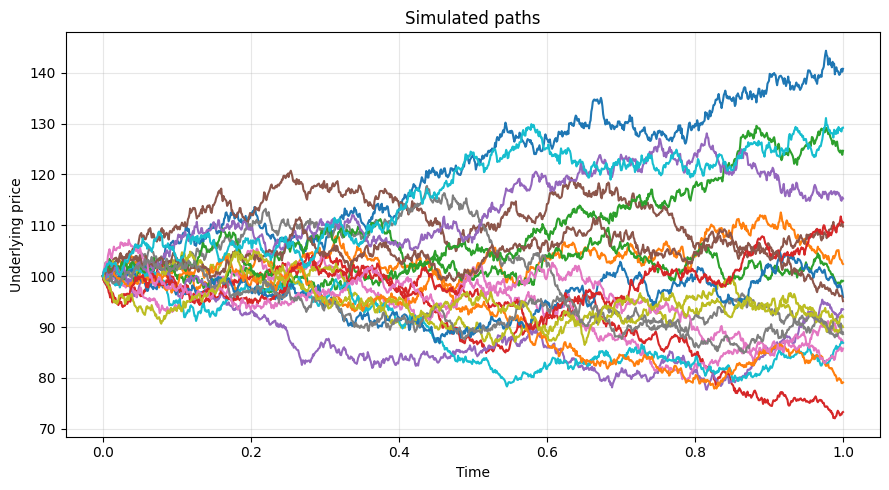

In [144]:
PRICER.simulate_paths(plot_paths=True)

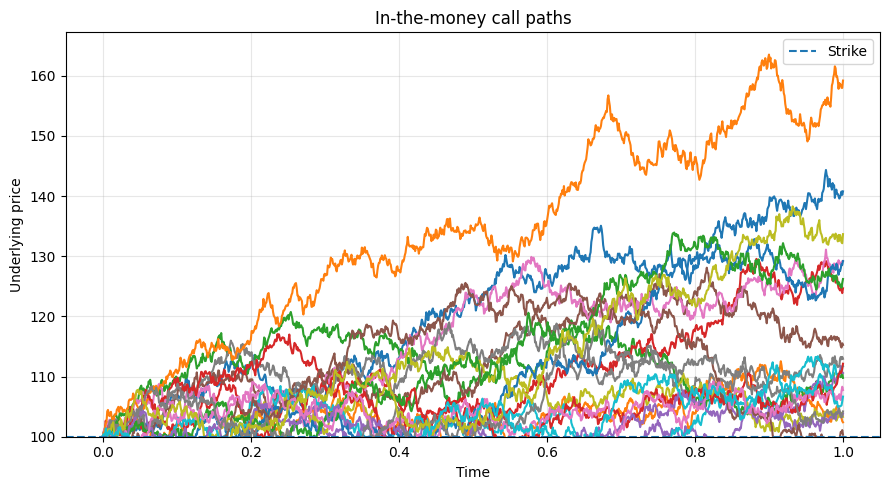

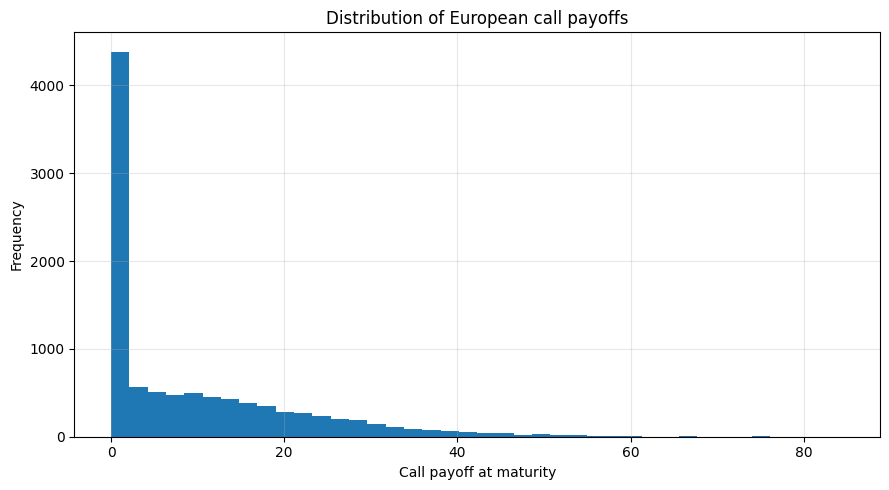

,Option Type,Price,Standard Error,95% CI Lower,95% CI Upper
0,call,8.921128,0.113029,8.699592,9.142664


,Option Type,Price,Standard Error,95% CI Lower,95% CI Upper
0,put,3.459811,0.060995,3.340261,3.57936


In [146]:
call = PRICER.price_european_voption(
    option_type="call", plot_paths=True, plot_payoffs=True
)
put = PRICER.price_european_voption(
    option_type="put", plot_paths=False, plot_payoffs=False
)
display(call)
display(put)